# 異常検知
---
## 目的
知識蒸留を用いた異常検知アルゴリズムを設計する．

## 問題設定
- 事前に入手できるデータは正常データのみ．
- 画素レベルでの異常検知を行う．


### データセットのダウンロード
異常検知用のデータセットを[ここ](https://drive.google.com/file/d/1L6uUT9n_jyVVDx6lXtssusdgCbpSve3n/view?usp=sharing)からダウンロードし，`./dataset`にコピーする．<br>
- 次のパス関係にする．<br>
``./dataset/mvtec_anomaly_detection.zip ``



- 先ほどダウンロードした異常検知用のデータセットファイル「mvtec_anomaly_detection.zip」を次のコードを実行して解凍する．<br>
 **$\ast$"mvtec_folder_path"は，「mvtec_anomaly_detection.zip」があるパスを指定する．**

In [ ]:
import tarfile

#---データセットファイルをコピーしたパスを指定---------------------------------#
mvtec_folder_path = './dataset/mvtec_anomaly_detection'
#------------------------------------------------------------------------------#

#---「mvtec_anomaly_detection.zip」を解凍--------------------------------------#
print("現在のカレントディレクトリ：")
!pwd

print("ファイル{0}を解凍中...".format(mvtec_folder_path))
zip_file_path = mvtec_folder_path + '.zip'
!unzip 'dataset/mvtec_anomaly_detection' -d 'dataset/'
#------------------------------------------------------------------------------#

現在のカレントディレクトリ：
/content
ファイルdrive/MyDrive/Colab Notebooks/mvtec_anomaly_detectionを解凍中...
Archive:  drive/MyDrive/Colab Notebooks/mvtec_anomaly_detection.zip
replace drive/MyDrive/Colab Notebooks/mvtec_anomaly_detection/bottle/license.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

---

### 必要なパッケージをインストール
はじめに必要なパッケージをインストールする．

In [3]:
import os
import cv2
import copy
import numpy as np
from glob import glob
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
import cv2

import torch
import torch.optim
import torch.nn as nn
import torchvision.models as models
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms as T
import torchvision

### GPUの確認

In [4]:
use_cuda = torch.cuda.is_available()
print('Use CUDA:', use_cuda)
!nvidia-smi

Use CUDA: True
Wed May  4 05:24:25 2022       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 496.13       Driver Version: 496.13       CUDA Version: 11.5     |
|-------------------------------+----------------------+----------------------+
| GPU  Name            TCC/WDDM | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  NVIDIA GeForce ... WDDM  | 00000000:0A:00.0  On |                  N/A |
|  0%   40C    P8    11W / 120W |   2161MiB /  6144MiB |     23%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                         

### 本アルゴリズムのパラメータを定義
本アルゴリズムでのパラメータを定義する．
- `dataset_path`: データセットまでのパス．
- `category_name`: 評価するデータセットのクラス．
- `batch_size`: ミニバッチ学習でのバッチサイズ．
- `epochs`: 学習フェーズでのエポック回数．
- `model_path`: 学習フェーズで学習したモデルを保存するディレクトリのパス．
- `model_name`: 学習済みモデルの保存名．
- `model_full_path`: 保存する学習済みモデルのパス．

In [ ]:
phase = 'train'

dataset_path = 'drive/MyDrive/Colab Notebooks/mvtec_anomaly_detection'
category_name = 'bottle'
batch_size = 32
epochs = 100

model_path = os.path.join("5","models")
model_name = "best.pth.tar"
model_full_path = os.path.join(model_path, category_name, model_name)


### データセットを読み込むためのクラスを定義
本実験では，異常検知用のデータセットである[MVTec-AD](https://www.mvtec.com/company/research/datasets/mvtec-ad)を用いる．<br>

<left>
<img src=https://dsm01pap004files.storage.live.com/y4mn7IMDem3LvNEqwKn5FxGAcQUomZywT7J8Dz-umbmbXtKduQPqT6jo_MEvjkidbP7Fhv69jfHqiOUGVm2xOSiC3wqtfSxBJ8sG6CBL6Z1C0rnhgfaabzHta7yqazGlXyD6s5ThqtnDj9k2TH_RTLI4iZMtOAYg_h3gDMuOdreOuQYypYiIY4vwf9c5uiYH5lb?width=2832&height=1706&cropmode=none width=30%>
<br>
<em>図1: MVTec-ADの画像例．</em>
</left>

そのために，データセットMVTec-ADを読み込むためのデータセットクラスを定義する．<br>
`class MVTecDataset()`は，呼び出し時に「データセットの画像までのパス」と「前処理の適用設定」の2点を入力として与える．<br>
（データセットクラスの定義については，[Not yet..](https://github.com/team-Kwork/Tutorial/blob/master/src/4_usage_dataset.ipynb)を参照．）
<br><br>
<b>インスタンス変数</b>
- `image_list`: データセットの画像までのパス．
- `transform`: 前処理としての変換処理．
- `dataset`: リスト型で格納されたRGB画像．

In [ ]:
class MVTecDataset(object):
    def __init__(self, image_list, transform=None):
        self.image_list = image_list
        self.transform = transform
        if self.transform is None:
            self.transform = T.ToTensor()
        self.dataset = self.load_dataset()

    def load_dataset(self):
        return [Image.open(p).convert('RGB') for p in self.image_list]

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image = self.transform(self.dataset[idx])
        return self.image_list[idx], image

def load_gt(root, cls):
    gt = []
    gt_dir = os.path.join(root, cls, 'ground_truth')
    sub_dirs = sorted(os.listdir(gt_dir))
    for sb in sub_dirs:
        for fname in sorted(os.listdir(os.path.join(gt_dir, sb))):
            temp = cv2.imread(os.path.join(gt_dir, sb, fname), cv2.IMREAD_GRAYSCALE)
            temp = cv2.resize(temp, (256, 256)).astype(np.bool8)[None, ...]
            gt.append(temp)
    gt = np.concatenate(gt, 0)
    return gt

def denormalization(x):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    x = (((x.transpose(1, 2, 0) * std) + mean) * 255.).astype(np.uint8)
    return x

### 前処理を定義
入力画像に適用する前処理を定義する．<br>
前処理は，データ分析を容易にするだけでなく，意味のあるパターンを導くために重要な処理である．<br><br>
<b>適用する前処理</b>
- `ToTensor()`: 呼び出したデータ型をTensor型に変換．
- `Resize([width,height])`: 画像の横・縦サイズを指定．
- `Normalize()`: データを正規化するクラス．

In [ ]:
transform = T.Compose([
    T.ToTensor(),
    T.Resize([256, 256]),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

### 学習用データセットの作成
未学習のモデルを学習する際に，定義したモデルがどの程度の汎化性能に達しているかを評価する必要がある．<br>
そこで，モデルの学習程度を検証するために，データを「学習用データセット」と「検証用データセット」に分割する．<br>
今回は，「学習用データセット」と「検証用データセット」を$8:2$で分割する．

In [ ]:
# 画像までのパス
image_list = sorted(glob(os.path.join(dataset_path, category_name, 'train', 'good', '*.png')))

# データセットを分割
train_image_list, val_image_list = train_test_split(image_list, test_size=0.2, random_state=0)
# 学習用データセット生成
train_dataset = MVTecDataset(train_image_list, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=False)
# 検証用データセット生成
val_dataset = MVTecDataset(val_image_list, transform=transform)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, drop_last=False)

次に，学習データを表示する．

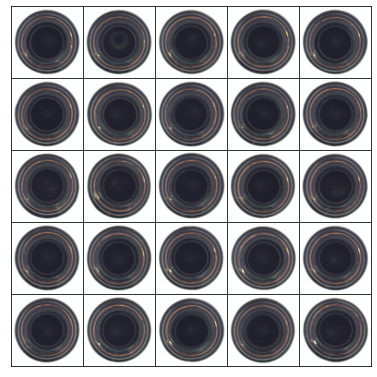

In [ ]:
# 学習データを表示
nrows = 5
ncols = 5
fig_img, ax_img = plt.subplots(nrows, ncols, figsize=(5, 5))
fig_img.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0, wspace=0)

for i in range(nrows):
  for j in range(ncols):
    ax_img[i,j].axes.xaxis.set_visible(False)
    ax_img[i,j].axes.yaxis.set_visible(False)

for i in range(nrows):
  for j in range(ncols):
    count = i*nrows + j
    t_idx = i*nrows + j
    _, img = train_dataset[t_idx]
    img = denormalization(img.numpy())
    out_img = img
    
    ax_img[i, j].xaxis.set_major_locator(plt.NullLocator())
    ax_img[i, j].yaxis.set_major_locator(plt.NullLocator())
    ax_img[i,j].imshow(out_img)


### テスト用データセットを作成
テスト用データセットを作成する．<br>
ここで可視化の容易性を考えて，異常データから構成される「異常データセット」と正常データから構成される「正常データセット」を作成する．<br>
注意点として，これらのデータは学習データとは異なるデータである．<br>


In [ ]:
test_neg_image_list = sorted(glob(os.path.join(dataset_path, category_name, 'test', 'good', '*.png')))
test_pos_image_list = set(glob(os.path.join(dataset_path, category_name, 'test', '*', '*.png'))) - set(test_neg_image_list)
test_pos_image_list = sorted(list(test_pos_image_list))
test_neg_dataset = MVTecDataset(test_neg_image_list, transform=transform)
test_pos_dataset = MVTecDataset(test_pos_image_list, transform=transform)
test_neg_loader = DataLoader(test_neg_dataset, batch_size=1, shuffle=False, drop_last=False)
test_pos_loader = DataLoader(test_pos_dataset, batch_size=1, shuffle=False, drop_last=False)

次に，テストデータ（異常データ）を可視化する．

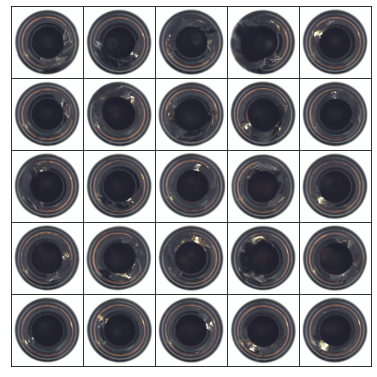

In [ ]:
# テストデータ（異常画像）を表示
nrows = 5
ncols = 5
fig_img, ax_img = plt.subplots(nrows, ncols, figsize=(5, 5))
fig_img.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0, wspace=0)

for i in range(nrows):
  for j in range(ncols):
    ax_img[i,j].axes.xaxis.set_visible(False)
    ax_img[i,j].axes.yaxis.set_visible(False)

for i in range(nrows):
  for j in range(ncols):
    count = i*nrows + j
    t_idx = i*nrows + j
    _, img = test_pos_dataset[t_idx]
    img = denormalization(img.numpy())
    out_img = img
    
    ax_img[i, j].xaxis.set_major_locator(plt.NullLocator())
    ax_img[i, j].yaxis.set_major_locator(plt.NullLocator())
    ax_img[i,j].imshow(out_img)
    

### ネットワーク構造の定義
本アルゴリズムでは，画像認識分野において高い精度を達成しているResNet18を利用して画像から特徴量を抽出する．<br>
そのために，順伝搬の際にレイヤーグループ「4」「5」「6」からの特徴量マップを返り値として返すネットワークモデルを定義する．<br>
この順伝搬関数`forward`では，定義した層を接続して処理するようにデザインする．<br>
今回の目的は，レイヤーグループ「4」「5」「6」での出力である特徴マップを得ることであるため，<br>
1. `for`文を用いて，定義したネットワークのBottom layersからTop layersへと順番にデータ$x$を与える．
2. レイヤーグループの`name`が「4」「5」「6」であれば，その出力結果である特徴マップ$F^{l}(I_{k})\in\mathbb{R}^{w_{l}\times h_{l} \times d_{l}}$をリスト`res`に格納．

とする．<br>
（ネットワークモデルの定義については，[not yet]()を参照．）

In [ ]:
class ResNet18_MS3(nn.Module):
    
    def __init__(self, pretrained=False):
        super(ResNet18_MS3, self).__init__()
        # ResNet18を定義
        net = models.resnet18(pretrained=pretrained)

        # Wide ResNetのレイヤーグループ[6]以降は必要ないため，今回のモデルではそれ以前のレイヤーグループのみを定義
        self.model = torch.nn.Sequential(*(list(net.children())[:-2]))

    def forward(self, x):
        res = []
        for name, module in self.model._modules.items():
            x = module(x)
            if name in ['4', '5', '6']:
                res.append(x)
        return res

### 本アルゴリズムの流れ
本アルゴリズム[Wang et al. BMVC2021](https://arxiv.org/abs/2103.04257v3)は，特徴量に基づいた知識蒸留のフレームワークによる異常検知手法である．<br>

<left>
<img src=https://dsm01pap004files.storage.live.com/y4maDLX2A_G2KdI-do10h7xZICuzkExHQ0NAMdVkTgysUQ6xhfG-ZbRNieIwr_iX3TUkOCg42plTaPvlzG7JyR-JCDXSI-UHqfcYOifFp7EuvT6_ejnKkqAUmJY4-eiythNtqW1IOp8AVoWiCvuGGe5Gp7VcmtUmVJ8_II-0dTXUcLsXXNca1AKDrpHVlhjbt6y?width=701&height=393&cropmode=none width=60%>
<br>
<em>図2: 本アルゴリズムの概要 [Wang et al. BMVC2021]．</em>
</left>

今回の問題として，学習データは正常画像のみから構成される．<br>
具体的には，図2に示すように，教師ネットワークと生徒ネットワークでの学習から，正常画像の特徴分布をモデル化します．<br>
ここで，教師ネットワーク`teacher`は事前学習済みのネットワーク，生徒ネットワーク`student`は未学習ネットワークを用います．<br>


学習フェーズでは，正常画像における教師ネットワークの出力を生徒ネットワークが模倣することが目的となる．<br>
各ネットワークは`class ResNet18_MS3()`で定義したように，3つの層で計算された特徴マップをそれぞれ返す．<br>
これを定式化すると，学習データ$\mathcal{D}=\{I_{1},I_{2},\ldots,I_{N} \}, I_{k}\in \mathbb{R}^{w \times h \times c}$を与えたとき，$l$番目のレイヤーグループにおける教師ネットワークの特徴マップを$F_{t}^{l}(I_{k})\in\mathbb{R}^{w_{l}\times h_{l} \times d_{l}}$と，生徒ネットワークの特徴マップを$F_{s}^{l}(I_{k})\in\mathbb{R}^{w_{l}\times h_{l} \times d_{l}}$とする．<br>
また，画像上の位置における特徴量を明確にすると，特徴マップの$(i,j)$画素目の特徴ベクトルは$F_{t}^{l}(I_{k})_{ij}\in\mathbb{R}^{d_{l}}$，$F_{s}^{l}(I_{k})_{ij}\in\mathbb{R}^{d_{l}}$となる．<br>

次に，学習フェーズの目的である「正常画像における教師ネットワークの出力を生徒ネットワークが模倣する」を損失関数として次のように定義する．<br>
\begin{equation}
L^{l}(I_{k})_{ij}=\frac{1}{2} \| \hat{F}_{t}^{l}(I_{k})_{ij} -  \hat{F}_{s}^{l}(I_{k})_{ij} \|_{2}^{2}\\
\hat{F}_{t}^{l}(I_{k})_{ij}=\frac{F_{t}^{l}(I_{k})_{ij}}{\|\hat{F}_{t}^{l}(I_{k})_{ij}\|_{2}^{2}}, \hspace{5pt} \hat{F}_{t}^{l}(I_{k})_{ij}=\frac{F_{t}^{l}(I_{k})_{ij}}{\|\hat{F}_{t}^{l}(I_{k})_{ij}\|_{2}^{2}} 
\tag{1}
\end{equation}

ここで，$\hat{F}^{l}(I_{k})_{ij}$は$\ell_{2}$-正規化特徴ベクトルでるため，損失関数$L^{l}(I_{k})_{ij}$はコサイン距離の特性を持つ（i.e., $L^{l}(I_{k})_{ij} \in [0,1]$）．<br>
画像$I_{k}$での最終的な損失は平均を取ることで次のように定義する．
\begin{equation}
L^{l}(I_{k})=\frac{1}{w_{l}h_{l}} \sum_{i=1}^{w_{l}} \sum_{j=1}^{h_{l}} L^{l}(I_{k})_{ij}
\tag{2}
\end{equation}
加えて，最終的な損失は，異なるスケールのレイヤーグループの平均によって重み付けされる．
\begin{equation}
L(I_{k})=\sum_{l=1}^{L} \alpha_{l} L^{l}(I_{k})
\tag{3}
\end{equation}
具体的な実装は次以降に示す．



### 教師ネットワークと生徒ネットワークの定義
初めに教師ネットワーク`teacher`は事前学習済みのネットワーク，生徒ネットワーク`student`は未学習ネットワークを定義します．<br>

In [ ]:
teacher = ResNet18_MS3(pretrained=True)
student = ResNet18_MS3(pretrained=False)
teacher.cuda()
student.cuda()

Downloading: "https://download.pytorch.org/models/wide_resnet50_2-95faca4d.pth" to /root/.cache/torch/hub/checkpoints/wide_resnet50_2-95faca4d.pth


  0%|          | 0.00/132M [00:00<?, ?B/s]

ResNet18_MS3(
  (model): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(128, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0): Co

### 学習フェーズの処理を実装
学習フェーズでは，基本的にテストフェーズと同様の処理で実装することが可能である．
<br>
教師ネットワークは事前学習済み，生徒ネットワークは未学習である．
具体的には，
1. 教師ネットワーク`teacher`と生徒ネットワーク`student`に学習データ$\mathcal{D}=\{I_{1},I_{2},\ldots,I_{N} \}$を与えることで，各特徴マップ$F_{t}^{l}(I_{k})$と$F_{s}^{l}(I_{k})$を獲得する．<br>
2. 各特徴マップ$F_{t}^{l}(J)$と$F_{s}^{l}(J)$を$\ell_{2}$-正規化することで$\hat{F}_{t}^{l}(J)_{ij}$と$\hat{F}_{t}^{l}(J)_{ij}$を計算する．<br>
3. 式(1)に示す損失$L^{l}(J)_{ij}$を計算する．<br>
4. 画像$I_{k}$での最終的な損失$L^{l}(I_{k})$を式(2)から計算する．
5. 最終的な全スケールでの損失$L(I_{k})$は，式(3)による異なるスケールのレイヤーグループの平均によって重み付けされる．
6. 逆伝搬ステップ
7. 最適化ステップ



**変数の対応関係**<br>
- 教師ネットワーク: `teacher`
- 生徒ネットワーク: `student`
- 学習データ $\mathcal{D}$: `batch_data`
- 特徴マップ（教師ネットワークによる）$F_{t}^{l}(I_{k})$: `t_feat`
- 特徴マップ（生徒ネットワークによる）$F_{s}^{l}(I_{k})$: `s_feat`
- 最終的な全スケールでの損失$L(I_{k})$: `loss`

In [ ]:
def train(teacher, student, train_loader, epochs):
    min_err = 10000
    teacher.eval()
    student.train()

    optimizer = torch.optim.SGD(student.parameters(), 0.4, momentum=0.9, weight_decay=1e-4)
    for epoch in range(epochs):
        for batch_data in train_loader:
            _, batch_img = batch_data
            batch_img = batch_img.cuda()

            with torch.no_grad():
                t_feat = teacher(batch_img)
            s_feat = student(batch_img)

            loss =  0
            for i in range(len(t_feat)):
                t_feat[i] = F.normalize(t_feat[i], dim=1)
                s_feat[i] = F.normalize(s_feat[i], dim=1)
                loss += torch.sum((t_feat[i] - s_feat[i]) ** 2, 1).mean()

            print('[%d/%d] loss: %f' % (epoch, epochs, loss.item()))
            # 
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

### テストフェーズの処理を実装
テストフェーズでは，入力画像$J \in \mathbb{R}^{w \times h \times c}$が与えられたときに，式(1)で定義した損失関数に基づいて異常スコアマップ$\Omega(J) \in \mathbb{R}^{w \times h}$を計算する．<br>
ここで教師ネットワークは事前学習済み，生徒ネットワークは知識蒸留によって学習ステップで学習したネットワークである．<br>
具体的には，
1. 教師ネットワーク`teacher`と生徒ネットワーク`student`に入力データ$J$を与えることで，各特徴マップ$F_{t}^{l}(J)$と$F_{s}^{l}(J)$を獲得する．<br>
2. 各特徴マップ$F_{t}^{l}(J)$と$F_{s}^{l}(J)$を$\ell_{2}$-正規化することで$\hat{F}_{t}^{l}(J)_{ij}$と$\hat{F}_{t}^{l}(J)_{ij}$を計算する．<br>
3. 式(1)に示す損失$L^{l}(J)_{ij}$を計算する．<br>
4. 各画素値$(i,j)$に損失$L^{l}(J)_{ij}$を持つ損失マップをレイヤーグループ$l$に対応するスコアマップ$\Omega^{l}(J) \in \mathbb{R}^{w \times h}$として定義する．
5. 最終的な異常スコアマップ$\Omega(J) \in \mathbb{R}^{w \times h}$を各レイヤーグループ$l$から計算する．
\begin{equation}
\Omega(J)=\prod_{l=1}^{L} \Omega^{l}(J)
\tag{4}
\end{equation}

**変数の対応関係**<br>
- 教師ネットワーク: `teacher`
- 生徒ネットワーク: `student`
- 入力画像 $J$: `batch_img`
- 特徴マップ（教師ネットワークによる）$F_{t}^{l}(J)$: `t_feat`
- 特徴マップ（生徒ネットワークによる）$F_{s}^{l}(J)$: `s_feat`
- 損失マップ: `sm`
- 異常スコアマップ $\Omega(J)$: `score_map`

In [ ]:
def test(teacher, student, loader):
    teacher.eval()
    student.eval()
    score_maps = np.zeros((len(loader.dataset), 64, 64))
    i = 0
    for batch_data in loader:
        _, batch_img = batch_data
        batch_img = batch_img.cuda()
        # 特徴マップを計算
        with torch.no_grad():
            t_feat = teacher(batch_img)
            s_feat = student(batch_img)
        score_map = 1.
        for j in range(len(t_feat)):
            # 正規化 
            t_feat[j] = F.normalize(t_feat[j], dim=1)
            s_feat[j] = F.normalize(s_feat[j], dim=1)
            # 式(1)を計算
            sm = torch.sum((t_feat[j] - s_feat[j]) ** 2, 1, keepdim=True)
            # 損失マップのサイズを各スケールで合わせる
            sm = F.interpolate(sm, size=(64, 64), mode='bilinear', align_corners=False)

            # 式(4)を計算する
            score_map = score_map * sm
        score_maps[i: i + batch_img.size(0)] = score_map.squeeze().cpu().data.numpy()
        i += batch_img.size(0)
    return score_maps

### 学習+検証フェーズの処理を実装
先ほど作成した学習フェーズでの処理に検証処理を加えて，実装してみる．<br>
検証フェーズは，テストフェーズと同様の処理となる．<br>
学習+検証フェーズでは，各エポックで検証データによる損失を計算し，損失が`min_err`よりも小さくなる場合のモデルパラメータを保存する．

In [ ]:
def train_val(teacher, student, train_loader, val_loader, epochs, model_path, category_name, model_name):
  val_list = []
  min_err = 10000
  teacher.eval()
  student.train()

  optimizer = torch.optim.SGD(student.parameters(), 0.4, momentum=0.9, weight_decay=1e-4)
  for epoch in range(epochs):
    for batch_data in train_loader:
        _, batch_img = batch_data
        batch_img = batch_img.cuda()

        with torch.no_grad():
            t_feat = teacher(batch_img)
        s_feat = student(batch_img)

        loss =  0
        for i in range(len(t_feat)):
            t_feat[i] = F.normalize(t_feat[i], dim=1)
            s_feat[i] = F.normalize(s_feat[i], dim=1)
            loss += torch.sum((t_feat[i] - s_feat[i]) ** 2, 1).mean()

        print('[%d/%d] loss: %f' % (epoch, epochs, loss.item()))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    #---ここまでは学習フェーズ時に実装したコードと同じ---------------------#
    # 検証フェーズ
    err = test(teacher, student, val_loader).mean()
    print('Valid Loss: {:.7f}'.format(err.item()))
    val_list.append(err.item())
    if err < min_err:
        min_err = err
        save_name = os.path.join(model_path, category_name, model_name)
        dir_name = os.path.dirname(save_name)
        if dir_name and not os.path.exists(dir_name):
            os.makedirs(dir_name)
        state_dict = {
            'category': category_name,
            'state_dict': student.state_dict()
        }
        torch.save(state_dict, save_name)
  return val_list

### 学習を実行
これまでに実装した関数を用いて学習を行う．<br>
はじめに定義したパラメータのエポック数`epochs`だけ学習を実行する．<br>
その際に，検証データによる損失も`Valid Loss`として表示する．<br>
plot画像から，学習が進むにつれて検証データでの損失が少なくなっていることが確認できる．

In [ ]:
val_list = train_val(teacher, student, train_loader, val_loader, epochs, model_path, category_name, model_name)


[0/100] loss: 0.373467
[0/100] loss: 0.350110
[0/100] loss: 0.336199
[0/100] loss: 0.345184
[0/100] loss: 0.343345
[0/100] loss: 0.337924
Valid Loss: 0.0028508
[1/100] loss: 0.329057
[1/100] loss: 0.321990
[1/100] loss: 0.316394
[1/100] loss: 0.321502
[1/100] loss: 0.308883
[1/100] loss: 0.299382
Valid Loss: 0.0024381
[2/100] loss: 0.301740
[2/100] loss: 0.305603
[2/100] loss: 0.299859
[2/100] loss: 0.293335
[2/100] loss: 0.292607
[2/100] loss: 0.292445
Valid Loss: 0.0022256
[3/100] loss: 0.289064
[3/100] loss: 0.286474
[3/100] loss: 0.284049
[3/100] loss: 0.287496
[3/100] loss: 0.291590
[3/100] loss: 0.304067
Valid Loss: 0.0022307
[4/100] loss: 0.277842
[4/100] loss: 0.281913
[4/100] loss: 0.293525
[4/100] loss: 0.278789
[4/100] loss: 0.285775
[4/100] loss: 0.280924
Valid Loss: 0.0021082
[5/100] loss: 0.278436
[5/100] loss: 0.273759
[5/100] loss: 0.275253
[5/100] loss: 0.272038
[5/100] loss: 0.270009
[5/100] loss: 0.272758
Valid Loss: 0.0019767
[6/100] loss: 0.265863
[6/100] loss: 0.2

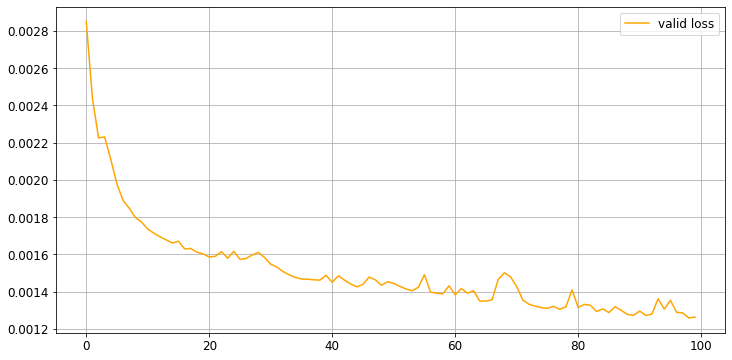

In [ ]:
x_list = range(len(val_list))
# グラフ表示
plt.figure(figsize=(12, 6))
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 12 

# plot loss values
plt.plot(x_list, val_list, color = "orange", linestyle = "solid" , label= 'valid loss')
plt.legend()
plt.grid()

plt.show()
plt.close()

### テストフェーズ
学習で保存したパラメータモデルを用いて，テストデータの異常検知を行う．<br>



In [ ]:
saved_dict = torch.load(model_full_path)
category = category_name
gt = load_gt(dataset_path, category)

print('load ' + model_full_path)
student.load_state_dict(saved_dict['state_dict'])

pos = test(teacher, student, test_pos_loader)
neg = test(teacher, student, test_neg_loader)

scores = []
for i in range(len(pos)):
    temp = cv2.resize(pos[i], (256, 256))
    scores.append(temp)
for i in range(len(neg)):
    temp = cv2.resize(neg[i], (256, 256))
    scores.append(temp)

scores = np.stack(scores)
neg_gt = np.zeros((len(neg), 256, 256), dtype=np.bool8)
gt_pixel = np.concatenate((gt, neg_gt), 0)
gt_image = np.concatenate((np.ones(pos.shape[0], dtype=np.bool8), np.zeros(neg.shape[0], dtype=np.bool8)), 0)

load 5/models/bottle/best.pth.tar


### 異常検知結果を可視化
テストデータでの異常検知結果を可視化する．<br>
今回は出力として，入力データ，正解画像，異常検知スコア，異常検知結果を表示することを目標とする．

In [ ]:
#---可視化用関数-------------------------------------#
def mask_on_image(mask, image):
    out = copy.deepcopy(image)
    masked = np.where((mask == [255,0,0]).all(axis=2))

    a = 100/255
    out[masked] = out[masked] * (1-a) + mask[masked] * a

    return np.uint8(out)

def cvt2heatmap(gray):
    heatmap = cv2.applyColorMap(np.uint8(gray), cv2.COLORMAP_JET)
    return heatmap

def heatmap_on_image(heatmap, image):
    out = np.float32(heatmap)/255 + np.float32(image)/255
    out = out / np.max(out)
    return np.uint8(255 * out)
#-----------------------------------------------------------#

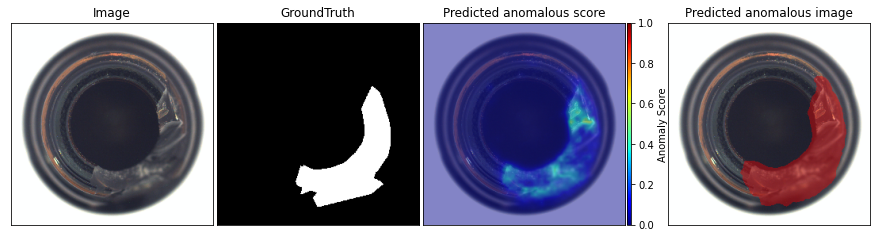

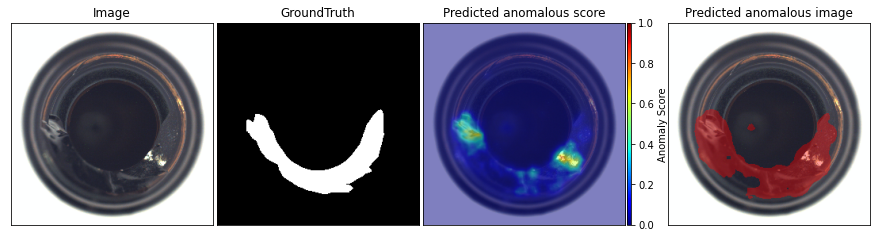

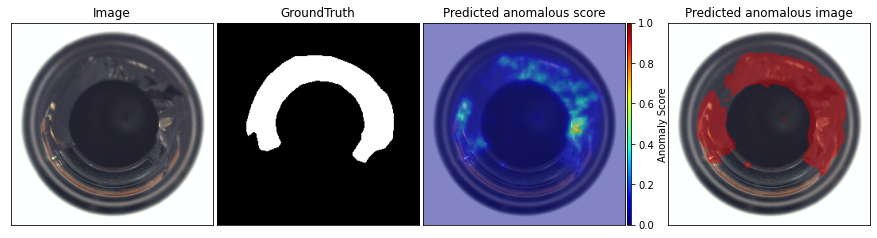

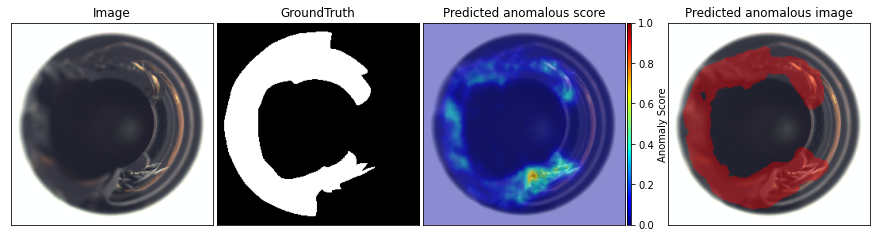

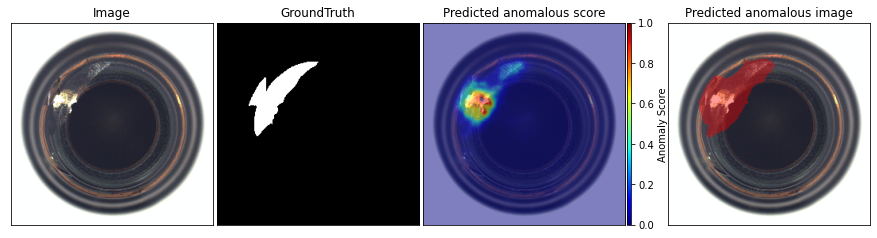

In [ ]:
#---しきい値を計算-----------------------------------#
precision, recall, thresholds = precision_recall_curve(gt_pixel.flatten(), scores.flatten())
a = 2 * precision * recall
b = precision + recall
f1 = np.divide(a, b, out=np.zeros_like(a), where=b != 0)
threshold = thresholds[np.argmax(f1)]
#-----------------------------------------------------------#

bar_max = 1 #np.max(scores)
bar_min = 0 #np.min(scores)

for i in range(5):
  t_idx = i
  # Set figure with subplots
  fig_img, ax_img = plt.subplots(1, 4, figsize=(12, 4))
  fig_img.subplots_adjust(left=0, right=0.95, bottom=0, top=1, wspace=0.02)
  for ax_i in ax_img:
      ax_i.axes.xaxis.set_visible(False)
      ax_i.axes.yaxis.set_visible(False)

  # Input image
  _, test_img = test_pos_dataset[t_idx]
  test_img = denormalization(test_img.numpy())
  ax_img[0].imshow(test_img)
  ax_img[0].title.set_text('Image')

  # Groundtruth of the input image
  test_gt = gt_pixel[t_idx]
  ax_img[1].imshow(test_gt, cmap='gray')
  ax_img[1].title.set_text('GroundTruth')

  # Predicted anomalous score
  feature_anomaly_map = (scores[t_idx] - bar_min)  / (bar_max - bar_min) # normalization
  heatmap = cv2.cvtColor(cvt2heatmap(feature_anomaly_map * 255), cv2.COLOR_BGR2RGB)
  test_heatmap = heatmap_on_image(heatmap, test_img)
  im = ax_img[2].imshow(feature_anomaly_map, vmin=0, vmax=1, cmap='jet')
  ax_img[2].title.set_text('Predicted anomalous score')
  axpos = ax_img[2].get_position()
  cbar_ax = fig_img.add_axes([axpos.x1+0.002, axpos.y0, 0.005, axpos.height])
  cbar = fig_img.colorbar(im, cax=cbar_ax)
  cbar.set_label("Anomaly Score")
  ax_img[2].imshow(test_heatmap)

  # Predicted anomalous image
  test_pred = copy.deepcopy(scores[t_idx])
  test_pred[test_pred <= threshold] = 0
  test_pred[test_pred > threshold] = 1
  zero_gt = np.zeros([test_pred.shape[0],test_pred.shape[1],1])
  mask = np.concatenate((np.expand_dims(test_pred, axis = 2),zero_gt,zero_gt), axis = 2)
  test_pred_img = mask_on_image(mask*255, test_img)
  axpos = ax_img[3].get_position()# adjust the space due because of the adding color bar
  ax_img[3].set_position([axpos.x0+0.045, axpos.y0, axpos.width, axpos.height])
  ax_img[3].imshow(test_pred_img)
  ax_img[3].title.set_text('Predicted anomalous image')
  #----------------------------------------------------------------#